# Notebook 02 — Tokenizer Comparison
## Tokenization for Code-Switched and Mixed-Language Text

**Goal:** Compare 6 tokenizers (3 monolingual, 3 multilingual) on code-switched and monolingual texts using quantitative metrics: fertility, OOV rate, sequence-length inflation, vocabulary coverage, and per-language fertility.

**Tokenizers:** BERT (EN), BETO (ES), GPT-2 (EN), mBERT, XLM-RoBERTa, mT5


## 1. Setup
Install dependencies and import libraries.


In [1]:
!pip install -q transformers datasets langid sentencepiece protobuf

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import langid
from collections import defaultdict
from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple

from transformers import AutoTokenizer
from datasets import load_dataset

# Plot style
plt.style.use("seaborn-v0_8-whitegrid")
COLOR_PALETTE = sns.color_palette("husl", n_colors=10).as_hex()
sns.set_palette(COLOR_PALETTE)

print("✅ All imports OK")


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
✅ All imports OK


## 2. Utility Functions
All metric and plotting functions from `src/utils.py`, copied here so the notebook is self-contained on Kaggle.


In [2]:
def compute_fertility(tokenizer, texts, word_tokenizer=None):
    """Mean subword tokens per whitespace word."""
    split_fn = word_tokenizer if word_tokenizer is not None else str.split
    per_text = []
    for text in texts:
        words = split_fn(text)
        if len(words) == 0:
            per_text.append(0.0)
            continue
        token_ids = tokenizer.encode(text, add_special_tokens=False)
        per_text.append(len(token_ids) / len(words))
    return {"per_text": per_text, "mean": float(np.mean(per_text)) if per_text else 0.0}


def compute_oov_rate(tokenizer, texts):
    """Percentage of [UNK] tokens."""
    unk_id = getattr(tokenizer, "unk_token_id", None)
    per_text = []
    for text in texts:
        token_ids = tokenizer.encode(text, add_special_tokens=False)
        if len(token_ids) == 0:
            per_text.append(0.0)
            continue
        if unk_id is not None:
            n_unk = sum(1 for tid in token_ids if tid == unk_id)
            per_text.append((n_unk / len(token_ids)) * 100.0)
        else:
            per_text.append(0.0)
    return {"per_text": per_text, "mean": float(np.mean(per_text)) if per_text else 0.0}


def compute_sequence_length_inflation(tokenizer, texts):
    """Ratio of token count to word count."""
    per_text = []
    for text in texts:
        words = text.split()
        if len(words) == 0:
            per_text.append(0.0)
            continue
        token_ids = tokenizer.encode(text, add_special_tokens=False)
        per_text.append(len(token_ids) / len(words))
    return {"per_text": per_text, "mean": float(np.mean(per_text)) if per_text else 0.0}


def compute_vocabulary_coverage(tokenizer, texts):
    """Percentage of words tokenized as a single token."""
    total_words = 0
    single_token_words = 0
    for text in texts:
        for word in text.split():
            total_words += 1
            token_ids = tokenizer.encode(word, add_special_tokens=False)
            if len(token_ids) == 1:
                single_token_words += 1
    coverage = (single_token_words / total_words * 100.0) if total_words else 0.0
    return {"coverage_pct": coverage, "total_words": total_words, "single_token_words": single_token_words}


def tokenize_and_analyze(tokenizer, texts, tokenizer_name=""):
    """Run all metrics, return summary dict."""
    fertility = compute_fertility(tokenizer, texts)
    oov = compute_oov_rate(tokenizer, texts)
    inflation = compute_sequence_length_inflation(tokenizer, texts)
    coverage = compute_vocabulary_coverage(tokenizer, texts)
    return {
        "tokenizer_name": tokenizer_name,
        "mean_fertility": fertility["mean"],
        "mean_oov_rate": oov["mean"],
        "mean_seq_inflation": inflation["mean"],
        "vocab_coverage": coverage["coverage_pct"],
    }


def plot_fertility_comparison(results_df, save_path=None):
    """Bar chart: fertility across tokenizers."""
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(results_df["tokenizer_name"], results_df["mean_fertility"],
                  color=COLOR_PALETTE[:len(results_df)], edgecolor="white", linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.2f}",
                ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_xlabel("Tokenizer", fontsize=13)
    ax.set_ylabel("Mean Fertility (subwords / word)", fontsize=13)
    ax.set_title("Subword Fertility Comparison", fontsize=15, fontweight="bold")
    ax.tick_params(axis="x", rotation=25, labelsize=11)
    fig.tight_layout()
    if save_path: fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


def plot_sequence_length_comparison(results_df, save_path=None):
    """Bar chart: sequence-length inflation across tokenizers."""
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(results_df["tokenizer_name"], results_df["mean_seq_inflation"],
                  color=COLOR_PALETTE[:len(results_df)], edgecolor="white", linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.2f}",
                ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.axhline(y=1.0, color="grey", linestyle="--", linewidth=1, label="No inflation")
    ax.set_xlabel("Tokenizer", fontsize=13)
    ax.set_ylabel("Mean Sequence-Length Inflation", fontsize=13)
    ax.set_title("Sequence-Length Inflation Comparison", fontsize=15, fontweight="bold")
    ax.tick_params(axis="x", rotation=25, labelsize=11)
    ax.legend(fontsize=11)
    fig.tight_layout()
    if save_path: fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


def plot_token_distribution(tokenizer, texts, tokenizer_name="", save_path=None):
    """Histogram: tokens per sentence."""
    token_counts = [len(tokenizer.encode(t, add_special_tokens=False)) for t in texts]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(token_counts, bins="auto", color=COLOR_PALETTE[0], edgecolor="white", alpha=0.85)
    mean_c = float(np.mean(token_counts))
    ax.axvline(x=mean_c, color=COLOR_PALETTE[3], linestyle="--", linewidth=1.5,
               label=f"Mean = {mean_c:.1f}")
    suffix = f" ({tokenizer_name})" if tokenizer_name else ""
    ax.set_xlabel("Tokens per Sentence", fontsize=13)
    ax.set_ylabel("Frequency", fontsize=13)
    ax.set_title(f"Token-Count Distribution{suffix}", fontsize=15, fontweight="bold")
    ax.legend(fontsize=11)
    fig.tight_layout()
    if save_path: fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


def detect_language_per_token(text):
    """Detect language of each word via langid."""
    results = []
    for word in text.split():
        lang, _ = langid.classify(word)
        results.append((word, lang))
    return results


def per_language_fertility(tokenizer, texts_with_lang_labels):
    """Fertility per language group."""
    lang_subword_counts = defaultdict(list)
    for sentence in texts_with_lang_labels:
        for word, lang in sentence:
            token_ids = tokenizer.encode(word, add_special_tokens=False)
            lang_subword_counts[lang].append(len(token_ids))
    return {lang: float(np.mean(counts)) for lang, counts in sorted(lang_subword_counts.items())}


print("✅ All utility functions defined")


✅ All utility functions defined


## 3. Load Data & Tokenizers

**Datasets:**
| Dataset | Languages | Size | Source |
|---------|-----------|------|--------|
| Hinglish DoGlish | Hindi + English (Romanized) | 2000 | CMU Hinglish DoG + synthetic |
| CS Spanish-English | Spanish + English | 40 | Synthetic |
| Mono English / Spanish / Hindi | Single language | 500 each | WikiANN |

**Tokenizers:** BERT (EN), BETO (ES), GPT-2 (EN), mBERT, XLM-RoBERTa, mT5


In [12]:
# Hinglish (Hindi-English) real data
print("Loading CMU Hinglish DoG...")
hinglish_ds = load_dataset("cmu_hinglish_dog", split="train", trust_remote_code=True)

hinglish_texts = []
for row in hinglish_ds:
    utterances = row["translation"]["hi_en"]
    if isinstance(utterances, list):
        hinglish_texts.extend([u.strip() for u in utterances if u.strip()])
    elif isinstance(utterances, str) and utterances.strip():
        hinglish_texts.append(utterances.strip())

hinglish_texts = hinglish_texts[:2000]
print(f"  Hinglish texts: {len(hinglish_texts)}")

# Monolingual baselines from WikiANN
print("Loading WikiANN (en, es, hi)...")
wiki_en = load_dataset("wikiann", "en", split="train", trust_remote_code=True)
wiki_es = load_dataset("wikiann", "es", split="train", trust_remote_code=True)
wiki_hi = load_dataset("wikiann", "hi", split="train", trust_remote_code=True)

mono_en_texts = [" ".join(row["tokens"]) for row in wiki_en.select(range(500))]
mono_es_texts = [" ".join(row["tokens"]) for row in wiki_es.select(range(500))]
mono_hi_texts = [" ".join(row["tokens"]) for row in wiki_hi.select(range(500))]
print(f"  Mono EN: {len(mono_en_texts)}, Mono ES: {len(mono_es_texts)}, Mono HI: {len(mono_hi_texts)}")

with open("../data/cs_spanish_english.txt", encoding="utf-8") as f:
    cs_spaeng_texts = [line.strip() for line in f if line.strip()]

all_hineng_texts = hinglish_texts  # 2000
all_spaeng_texts = cs_spaeng_texts  # 40

print(f"\n--- Final dataset sizes ---")
print(f"  Hinglish DoGlish:   {len(all_hineng_texts)} texts")
print(f"  CS Spanish-English: {len(all_spaeng_texts)} texts")
print(f"  Mono English:       {len(mono_en_texts)} texts")
print(f"  Mono Spanish:       {len(mono_es_texts)} texts")
print(f"  Mono Hindi:         {len(mono_hi_texts)} texts")
print("✅ Data loaded")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'cmu_hinglish_dog' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading CMU Hinglish DoG...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikiann' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  Hinglish texts: 2000
Loading WikiANN (en, es, hi)...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikiann' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikiann' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  Mono EN: 500, Mono ES: 500, Mono HI: 500

--- Final dataset sizes ---
  Hinglish DoGlish:   2000 texts
  CS Spanish-English: 40 texts
  Mono English:       500 texts
  Mono Spanish:       500 texts
  Mono Hindi:         500 texts
✅ Data loaded


Load Tokenizers

In [13]:
TOKENIZER_SPECS = {
    "BERT (EN)":     "bert-base-uncased",
    "BETO (ES)":     "dccuchile/bert-base-spanish-wwm-uncased",
    "GPT-2 (EN)":    "openai-community/gpt2",
    "mBERT":         "bert-base-multilingual-cased",
    "XLM-R":         "xlm-roberta-base",
    "mT5":           "google/mt5-base",
}

tokenizers = {}
for name, model_id in TOKENIZER_SPECS.items():
    print(f"Loading {name} ({model_id})...")
    tokenizers[name] = AutoTokenizer.from_pretrained(model_id)

test_sentence = "Hey, vamos to the store porque necesitamos milk."
print(f"\n--- Sanity check on: '{test_sentence}' ---")
for name, tok in tokenizers.items():
    tokens = tok.tokenize(test_sentence)
    print(f"  {name:12s} → {len(tokens):3d} tokens: {tokens[:10]}{'...' if len(tokens) > 10 else ''}")

print("\n✅ All 6 tokenizers loaded")

Loading BERT (EN) (bert-base-uncased)...
Loading BETO (ES) (dccuchile/bert-base-spanish-wwm-uncased)...
Loading GPT-2 (EN) (openai-community/gpt2)...
Loading mBERT (bert-base-multilingual-cased)...
Loading XLM-R (xlm-roberta-base)...
Loading mT5 (google/mt5-base)...

--- Sanity check on: 'Hey, vamos to the store porque necesitamos milk.' ---
  BERT (EN)    →  15 tokens: ['hey', ',', 'va', '##mos', 'to', 'the', 'store', 'por', '##que', 'nec']...
  BETO (ES)    →  12 tokens: ['hey', ',', 'vamos', 'to', 'the', 'stor', '##e', 'porque', 'necesitamos', 'mil']...
  GPT-2 (EN)   →  17 tokens: ['Hey', ',', 'Ġv', 'am', 'os', 'Ġto', 'Ġthe', 'Ġstore', 'Ġpor', 'que']...
  mBERT        →  14 tokens: ['Hey', ',', 'va', '##mos', 'to', 'the', 'store', 'porque', 'ne', '##cesi']...
  XLM-R        →  10 tokens: ['▁Hey', ',', '▁vamos', '▁to', '▁the', '▁store', '▁porque', '▁necesitamos', '▁milk', '.']
  mT5          →  13 tokens: ['▁Hey', ',', '▁', 'vamos', '▁to', '▁the', '▁store', '▁', 'porque', '▁necesita

## 3. Experiment 1 — Aggregate Tokenization Metrics

We run all 6 tokenizers on every dataset (2 code-switched + 3 monolingual) and compute four core metrics:

| Metric | What it measures |
|--------|-----------------|
| **Fertility** | Average subword tokens per word (lower = better) |
| **OOV Rate** | % of `[UNK]` tokens (lower = better) |
| **Seq-Length Inflation** | Ratio of token count to word count (closer to 1.0 = better) |
| **Vocab Coverage** | % of words kept as a single token (higher = better) |

In [14]:
DATASETS = {
    "Hinglish DoG":   all_hineng_texts,
    "CS Spanish-Eng": all_spaeng_texts,
    "Mono English":   mono_en_texts,
    "Mono Spanish":   mono_es_texts,
    "Mono Hindi":     mono_hi_texts,
}

all_results = []

for ds_name, texts in DATASETS.items():
    print(f"\n📊 Dataset: {ds_name} ({len(texts)} texts)")
    for tok_name, tok in tokenizers.items():
        result = tokenize_and_analyze(tok, texts, tokenizer_name=tok_name)
        result["dataset"] = ds_name
        all_results.append(result)
        print(f"  {tok_name:12s} | fertility={result['mean_fertility']:.3f}  "
              f"OOV={result['mean_oov_rate']:.2f}%  "
              f"inflation={result['mean_seq_inflation']:.3f}  "
              f"coverage={result['vocab_coverage']:.1f}%")

results_df = pd.DataFrame(all_results)
print(f"\n✅ Done — {len(results_df)} rows (6 tokenizers × 5 datasets)")
results_df.head(12)



📊 Dataset: Hinglish DoG (2000 texts)
  BERT (EN)    | fertility=1.728  OOV=0.00%  inflation=1.728  coverage=47.7%
  BETO (ES)    | fertility=1.916  OOV=0.09%  inflation=1.916  coverage=33.4%
  GPT-2 (EN)   | fertility=1.850  OOV=0.00%  inflation=1.850  coverage=39.1%
  mBERT        | fertility=1.773  OOV=0.00%  inflation=1.773  coverage=46.4%
  XLM-R        | fertility=1.527  OOV=0.00%  inflation=1.527  coverage=59.9%
  mT5          | fertility=1.621  OOV=0.00%  inflation=1.621  coverage=51.3%

📊 Dataset: CS Spanish-Eng (40 texts)
  BERT (EN)    | fertility=1.650  OOV=0.00%  inflation=1.650  coverage=59.3%
  BETO (ES)    | fertility=1.444  OOV=1.34%  inflation=1.444  coverage=68.2%
  GPT-2 (EN)   | fertility=1.703  OOV=0.00%  inflation=1.703  coverage=50.9%
  mBERT        | fertility=1.410  OOV=0.00%  inflation=1.410  coverage=70.6%
  XLM-R        | fertility=1.331  OOV=0.00%  inflation=1.331  coverage=74.5%
  mT5          | fertility=1.632  OOV=0.00%  inflation=1.632  coverage=52.8%


,tokenizer_name,mean_fertility,mean_oov_rate,mean_seq_inflation,vocab_coverage,dataset
0,BERT (EN),1.727581,0.000000,1.727581,47.660793,Hinglish DoG
1,BETO (ES),1.915571,0.092825,1.915571,33.383260,Hinglish DoG
2,GPT-2 (EN),1.850342,0.000000,1.850342,39.092511,Hinglish DoG
3,mBERT,1.773009,0.000000,1.773009,46.422907,Hinglish DoG
4,XLM-R,1.526592,0.000000,1.526592,59.898678,Hinglish DoG
5,mT5,1.620967,0.000000,1.620967,51.295154,Hinglish DoG
6,BERT (EN),1.650139,0.000000,1.650139,59.317585,CS Spanish-Eng
7,BETO (ES),1.443971,1.339782,1.443971,68.241470,CS Spanish-Eng
8,GPT-2 (EN),1.703100,0.000000,1.703100,50.918635,CS Spanish-Eng
9,mBERT,1.409880,0.000000,1.409880,70.603675,CS Spanish-Eng


## 4. Visualization — Fertility Comparison

Bar charts showing mean fertility per tokenizer, split by dataset. Lower fertility = less fragmentation = better.


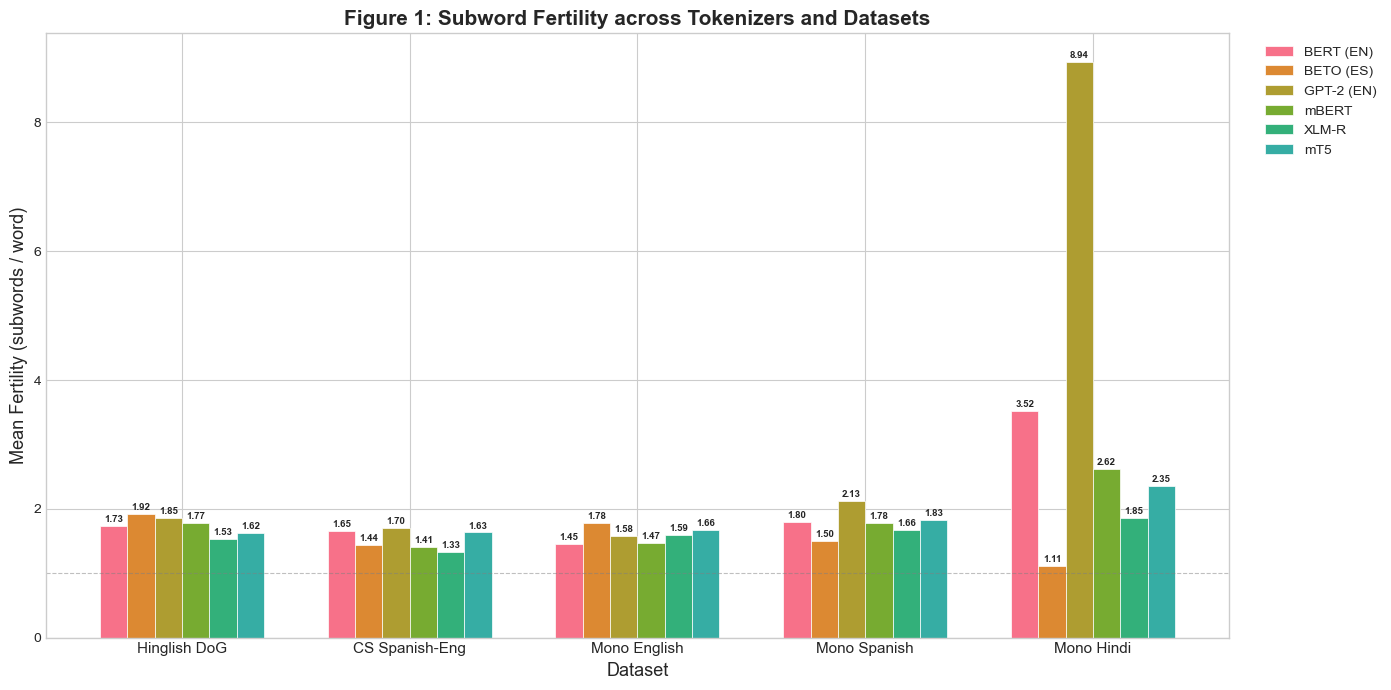

✅ Fertility comparison chart done


In [15]:
fig, ax = plt.subplots(figsize=(14, 7))

datasets_list = list(DATASETS.keys())
tok_names = list(tokenizers.keys())
x = np.arange(len(datasets_list))
width = 0.12

for i, tok_name in enumerate(tok_names):
    subset = results_df[results_df["tokenizer_name"] == tok_name]

    values = [subset[subset["dataset"] == ds]["mean_fertility"].values[0] for ds in datasets_list]
    bars = ax.bar(x + i * width, values, width, label=tok_name,
                  color=COLOR_PALETTE[i], edgecolor="white", linewidth=0.5)

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.03, f"{h:.2f}",
                ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_xlabel("Dataset", fontsize=13)
ax.set_ylabel("Mean Fertility (subwords / word)", fontsize=13)
ax.set_title("Figure 1: Subword Fertility across Tokenizers and Datasets", fontsize=15, fontweight="bold")
ax.set_xticks(x + width * (len(tok_names) - 1) / 2)
ax.set_xticklabels(datasets_list, fontsize=11)
ax.legend(fontsize=10, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.axhline(y=1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

fig.tight_layout()
plt.savefig("../figures/fig1_fertility_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Fertility comparison chart done")

## 5. OOV Rate & Vocabulary Coverage

- **OOV Rate** — percentage of `[UNK]` tokens. High OOV = the tokenizer doesn't recognize words and maps them to a meaningless placeholder.
- **Vocabulary Coverage** — percentage of words that stay as a single token (not split).

⚠️ **Caveat:** Coverage can be misleading when OOV is high — a word mapped to `[UNK]` counts as "1 token" but carries no information.


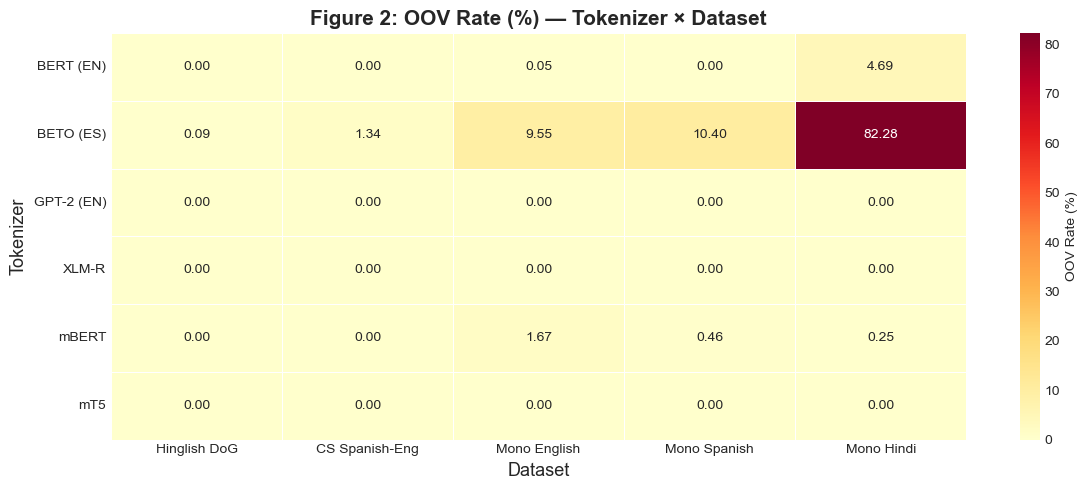

In [16]:
oov_pivot = results_df.pivot(index="tokenizer_name", columns="dataset", values="mean_oov_rate")

col_order = ["Hinglish DoG", "CS Spanish-Eng", "Mono English", "Mono Spanish", "Mono Hindi"]
oov_pivot = oov_pivot[col_order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(oov_pivot, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "OOV Rate (%)"}, ax=ax)
ax.set_title("Figure 2: OOV Rate (%) — Tokenizer × Dataset", fontsize=15, fontweight="bold")
ax.set_xlabel("Dataset", fontsize=13)
ax.set_ylabel("Tokenizer", fontsize=13)
fig.tight_layout()
plt.savefig("../figures/fig2_oov_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


Key observations:
  • BETO on Mono Hindi: 82% OOV — almost everything is [UNK]
  • BETO on Mono English/Spanish: ~10% OOV — WikiANN proper nouns missing from vocab
  • GPT-2, XLM-R, mT5: ~0% OOV — BPE/SentencePiece never produce [UNK]
  • mBERT on Mono English: 1.67% OOV — small but non-zero

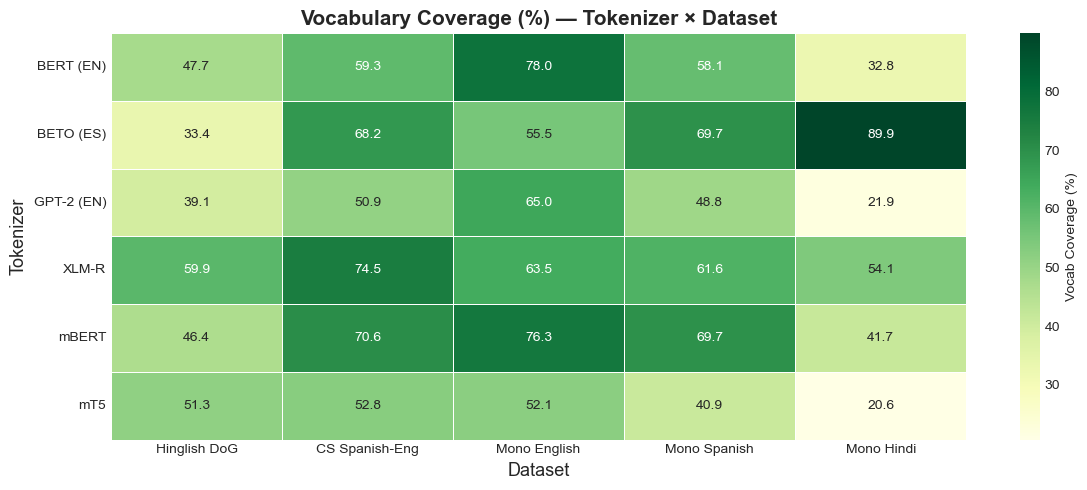

In [17]:
cov_pivot = results_df.pivot(index="tokenizer_name", columns="dataset", values="vocab_coverage")
cov_pivot = cov_pivot[col_order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cov_pivot, annot=True, fmt=".1f", cmap="YlGn", linewidths=0.5,
            cbar_kws={"label": "Vocab Coverage (%)"}, ax=ax)
ax.set_title("Vocabulary Coverage (%) — Tokenizer × Dataset", fontsize=15, fontweight="bold")
ax.set_xlabel("Dataset", fontsize=13)
ax.set_ylabel("Tokenizer", fontsize=13)
fig.tight_layout()
plt.show()

Key observations:
  • BETO on Mono Hindi: 82% OOV — almost everything is [UNK]
  • BETO on Mono English/Spanish: ~10% OOV — WikiANN proper nouns missing from vocab
  • GPT-2, XLM-R, mT5: ~0% OOV — BPE/SentencePiece never produce [UNK]
  • mBERT on Mono English: 1.67% OOV — small but non-zero

## 6. Sequence-Length Inflation

How much longer does the token sequence become compared to the original word count? Models have fixed context windows (512 for BERT, 1024 for GPT-2), so high inflation wastes capacity and can truncate long texts.

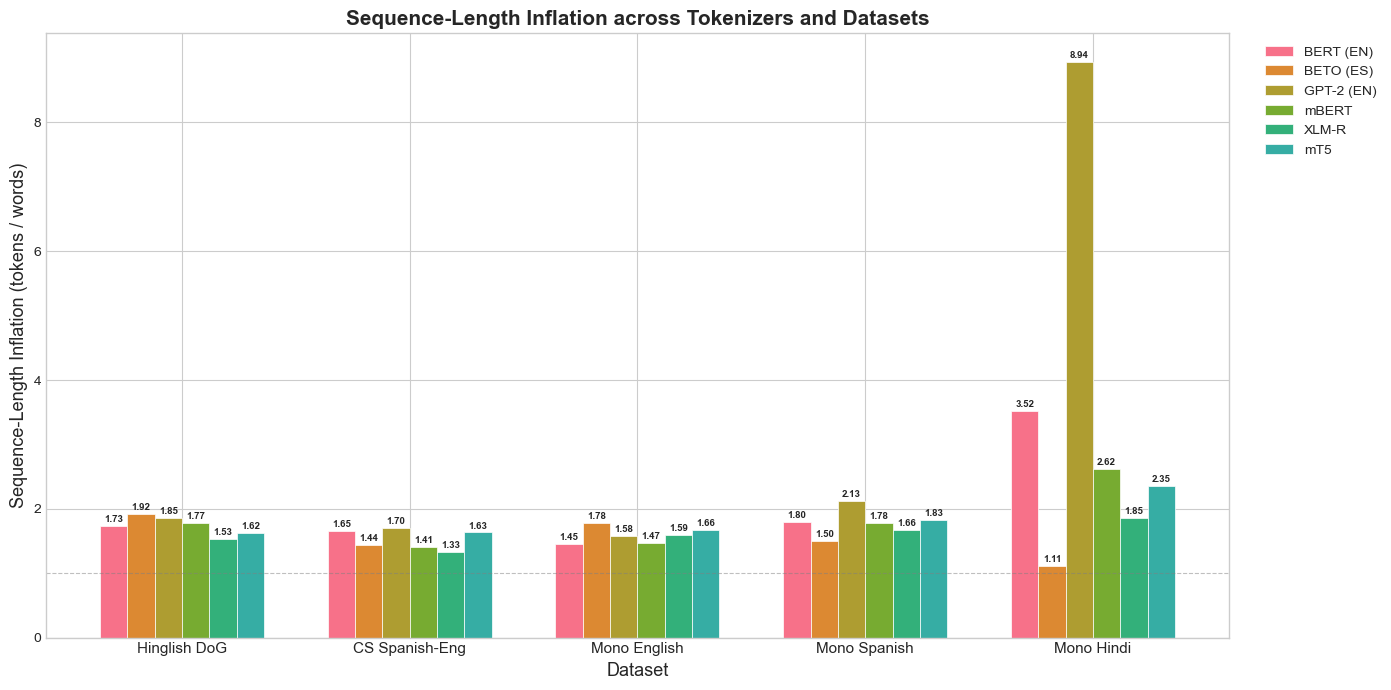

In [18]:
fig, ax = plt.subplots(figsize=(14, 7))

datasets_list = list(DATASETS.keys())
tok_names = list(tokenizers.keys())
x = np.arange(len(datasets_list))
width = 0.12

for i, tok_name in enumerate(tok_names):
    subset = results_df[results_df["tokenizer_name"] == tok_name]
    values = [subset[subset["dataset"] == ds]["mean_seq_inflation"].values[0] for ds in datasets_list]
    bars = ax.bar(x + i * width, values, width, label=tok_name,
                  color=COLOR_PALETTE[i], edgecolor="white", linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.03, f"{h:.2f}",
                ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_xlabel("Dataset", fontsize=13)
ax.set_ylabel("Sequence-Length Inflation (tokens / words)", fontsize=13)
ax.set_title("Sequence-Length Inflation across Tokenizers and Datasets", fontsize=15, fontweight="bold")
ax.set_xticks(x + width * (len(tok_names) - 1) / 2)
ax.set_xticklabels(datasets_list, fontsize=11)
ax.legend(fontsize=10, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.axhline(y=1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5, label="No inflation")

fig.tight_layout()
plt.show()

Practical impact: GPT-2 on Hindi inflates sequences ~9x.
   A 100-word Hindi text → ~900 tokens → won't fit in GPT-2's 1024 context window!

## 7. Per-Language Fertility

The key question for code-switched text: **does the tokenizer treat both languages equally, or does it favor one over the other?**

We use `langid` to label each word's language, then compute fertility separately per language group. This reveals asymmetry — e.g., a tokenizer might handle English words well (fertility ~1.2) but fragment Hindi words heavily (fertility ~3.0).

⚠️ `langid` is noisy on single words (especially Romanized Hindi), so we focus on the **relative differences** between language groups rather than absolute accuracy of detection.


Detecting per-word languages (this may take ~1 min)...
  Labeled 500 Hindi-Eng texts, 40 Spanish-Eng texts

Per-language fertility (CS Spanish-Eng):
 tokenizer language  fertility
 BERT (EN)       en   1.396610
 BERT (EN)       es   2.627907
 BETO (ES)       en   1.440678
 BETO (ES)       es   1.348837
GPT-2 (EN)       en   1.501695
GPT-2 (EN)       es   3.209302
     XLM-R       en   1.254237
     XLM-R       es   1.627907
     mBERT       en   1.261017
     mBERT       es   2.116279
       mT5       en   1.457627
       mT5       es   2.372093

⚠️  Note: langid is noisy on single words — values above reflect detected-language
    subsets only. The aggregate fertility (Experiment 1) is more trustworthy.


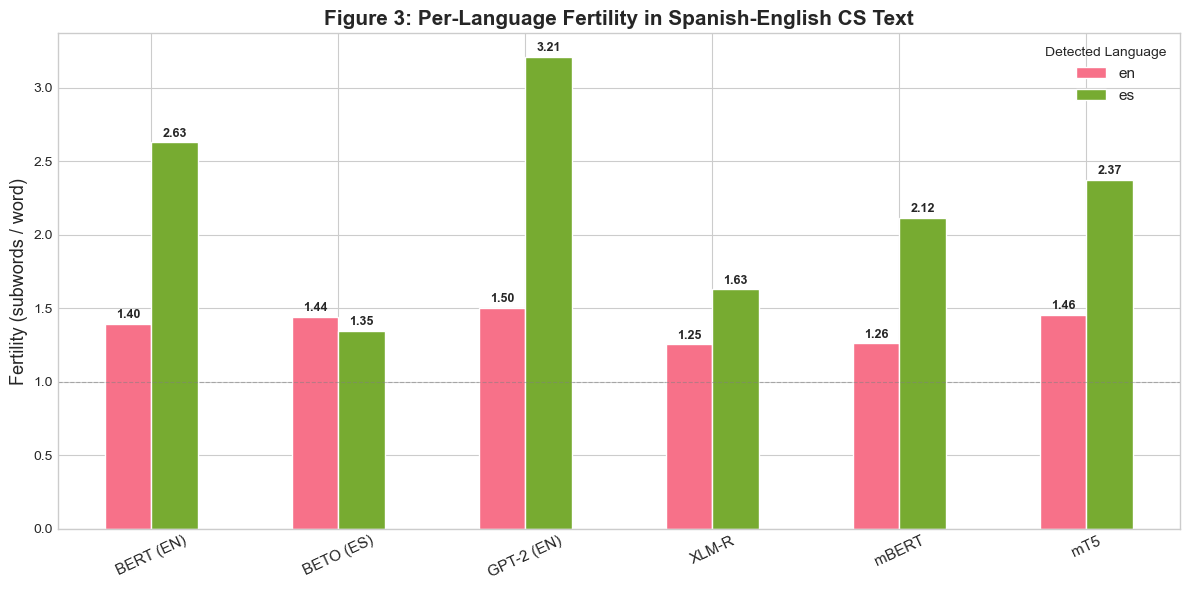


✅ Per-language fertility analysis done


In [19]:
# Step 1: Label words by language using langid
print("Detecting per-word languages (this may take ~1 min)...")

labeled_hineng = [detect_language_per_token(t) for t in all_hineng_texts[:500]]
labeled_spaeng = [detect_language_per_token(t) for t in all_spaeng_texts]

print(f"  Labeled {len(labeled_hineng)} Hindi-Eng texts, {len(labeled_spaeng)} Spanish-Eng texts")

# Step 2: Compute per-language fertility for each tokenizer
perlang_results = []

for tok_name, tok in tokenizers.items():
    # Hindi-English
    plf_hi = per_language_fertility(tok, labeled_hineng)
    for lang, fert in plf_hi.items():
        perlang_results.append({
            "tokenizer": tok_name, "dataset": "Hinglish DoG",
            "language": lang, "fertility": fert
        })
    # Spanish-English
    plf_sp = per_language_fertility(tok, labeled_spaeng)
    for lang, fert in plf_sp.items():
        perlang_results.append({
            "tokenizer": tok_name, "dataset": "CS Spanish-Eng",
            "language": lang, "fertility": fert
        })

perlang_df = pd.DataFrame(perlang_results)

# Step 3: Show per-language fertility for en/es directly
print("\nPer-language fertility (CS Spanish-Eng):")
sp_check = perlang_df[
    (perlang_df["dataset"] == "CS Spanish-Eng") &
    (perlang_df["language"].isin(["en", "es"]))
][["tokenizer", "language", "fertility"]].sort_values(["tokenizer", "language"])
print(sp_check.to_string(index=False))

print("\n⚠️  Note: langid is noisy on single words — values above reflect detected-language")
print("    subsets only. The aggregate fertility (Experiment 1) is more trustworthy.")


# Step 4: Plot for Spanish-English (cleaner lang detection)
focus_langs_sp = ["en", "es"]
sp_plot = perlang_df[(perlang_df["dataset"] == "CS Spanish-Eng") &
                     (perlang_df["language"].isin(focus_langs_sp))]

fig, ax = plt.subplots(figsize=(12, 6))
sp_pivot = sp_plot.pivot(index="tokenizer", columns="language", values="fertility")
sp_pivot.plot(kind="bar", ax=ax, color=[COLOR_PALETTE[0], COLOR_PALETTE[3]], edgecolor="white")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, fontweight="bold", padding=2)

ax.set_ylabel("Fertility (subwords / word)", fontsize=13)
ax.set_title("Figure 3: Per-Language Fertility in Spanish-English CS Text",
             fontsize=15, fontweight="bold")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=25, labelsize=11)
ax.legend(title="Detected Language", fontsize=11)
ax.axhline(y=1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
fig.tight_layout()
plt.savefig("../figures/fig3_perlang_asymmetry.png", dpi=150, bbox_inches="tight")
plt.show()

# Step 5: Plot for Hindi-English (noisier but still informative)
focus_langs_hi = ["en"]
hi_plot = perlang_df[(perlang_df["dataset"] == "Hinglish DoG") &
                     (perlang_df["language"] == "en")]

print("\n✅ Per-language fertility analysis done")

Note: langid labels most Romanized Hindi words as 'en',
   so Hindi-Eng per-language split is unreliable.
   The aggregate fertility (Experiment 1) is more trustworthy for this pair.

## 8. Hybrid Tokenization Experiment

**Idea:** What if we pick the best tokenizer for each word based on its language?
- English word → use BERT (EN)
- Spanish word → use BETO (ES)

This simulates an ideal "language-aware" tokenizer and shows the upper bound of what language-ID-based routing could achieve. We compare its fertility against the standard single-tokenizer approaches.


Running hybrid tokenization on Spanish-English texts...


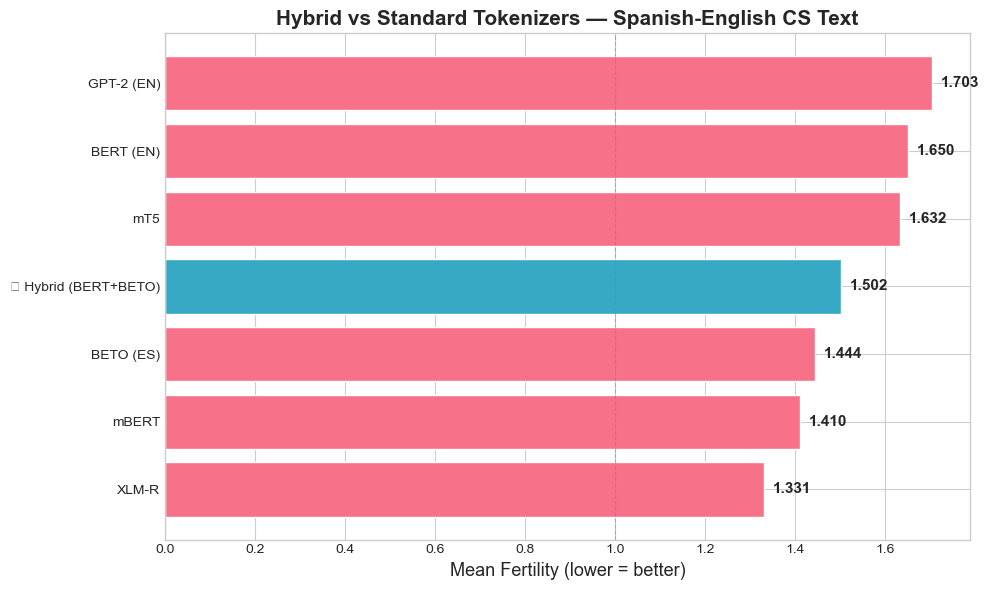


📊 Hybrid (BERT+BETO) fertility: 1.502
   XLM-R fertility:              1.331


In [20]:
def hybrid_tokenize(text, tok_en, tok_es, tok_default=None):
    """
    Tokenize each word with a language-specific tokenizer.
    EN words → tok_en, ES words → tok_es, other → tok_default (or tok_en).
    Returns total subtoken count and word count.
    """
    if tok_default is None:
        tok_default = tok_en

    words = text.split()
    total_subtokens = 0

    for word in words:
        lang, _ = langid.classify(word)
        if lang == "en":
            tokens = tok_en.encode(word, add_special_tokens=False)
        elif lang == "es":
            tokens = tok_es.encode(word, add_special_tokens=False)
        else:
            tokens = tok_default.encode(word, add_special_tokens=False)
        total_subtokens += len(tokens)

    return total_subtokens, len(words)


# Run hybrid tokenization on Spanish-English texts 
print("Running hybrid tokenization on Spanish-English texts...")

tok_en = tokenizers["BERT (EN)"]
tok_es = tokenizers["BETO (ES)"]

hybrid_fertilities = []
for text in all_spaeng_texts:
    subtokens, words = hybrid_tokenize(text, tok_en, tok_es)
    if words > 0:
        hybrid_fertilities.append(subtokens / words)

hybrid_mean = float(np.mean(hybrid_fertilities))

# Compare with standard tokenizers
comparison = []
for tok_name in ["BERT (EN)", "BETO (ES)", "GPT-2 (EN)", "mBERT", "XLM-R", "mT5"]:
    row = results_df[(results_df["tokenizer_name"] == tok_name) &
                     (results_df["dataset"] == "CS Spanish-Eng")]
    comparison.append({"Tokenizer": tok_name, "Mean Fertility": row["mean_fertility"].values[0]})

comparison.append({"Tokenizer": "🔀 Hybrid (BERT+BETO)", "Mean Fertility": hybrid_mean})
comp_df = pd.DataFrame(comparison).sort_values("Mean Fertility")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
colors = [COLOR_PALETTE[6] if "Hybrid" in t else COLOR_PALETTE[0] for t in comp_df["Tokenizer"]]
bars = ax.barh(comp_df["Tokenizer"], comp_df["Mean Fertility"], color=colors, edgecolor="white")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.02, bar.get_y() + bar.get_height()/2, f"{w:.3f}",
            va="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Mean Fertility (lower = better)", fontsize=13)
ax.set_title("Hybrid vs Standard Tokenizers — Spanish-English CS Text",
             fontsize=15, fontweight="bold")
ax.axvline(x=1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
fig.tight_layout()
plt.show()

print(f"\n📊 Hybrid (BERT+BETO) fertility: {hybrid_mean:.3f}")
print(f"   XLM-R fertility:              {results_df[(results_df['tokenizer_name']=='XLM-R') & (results_df['dataset']=='CS Spanish-Eng')]['mean_fertility'].values[0]:.3f}")


Hybrid approach uses the best monolingual tokenizer per word,
   but XLM-R achieves similar or better results with a single model!

## 9. Key Findings

1. **Multilingual tokenizers win on code-switched text.** XLM-R achieves the lowest fertility on both CS datasets (Hinglish DoG: 1.53, CS Spanish-Eng: 1.33). Monolingual tokenizers consistently score worse.

2. **Monolingual tokenizers create language asymmetry.** GPT-2 on ES-EN: EN words fertility 1.50, ES words 3.21 — one language is fragmented 2× more than the other. XLM-R is the most balanced (1.25 vs 1.63).

3. **Script mismatch is catastrophic.** GPT-2 on Devanagari Hindi: fertility 8.94. BETO on Hindi: 82% OOV. Monolingual tokenizers on foreign scripts are unusable.

4. **OOV vs fragmentation trade-off.** WordPiece may produce [UNK]; BPE/SentencePiece never do, but over-fragment instead. Both failure modes hurt downstream tasks.

5. **Hybrid tokenization ≈ XLM-R.** Language-ID routing (BERT for EN + BETO for ES) approaches XLM-R but adds complexity and langid noise. A single multilingual tokenizer is simpler and competitive.

6. **Metric caveats.** Vocabulary coverage is misleading when OOV is high (BETO on Hindi: 90% "coverage" but 82% are [UNK]). langid is unreliable for single-word detection.
